In [ ]:
# Install and import packages for TDA (ripser, persim, gudhi), optimal transport/Wasserstein (POT), and root-finding (brentq) used in the power/size experiments

!pip install ripser persim scikit-learn
!pip install gudhi POT
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt
from ripser import ripser
from ripser import Rips
from persim import wasserstein, plot_diagrams
from persim import PersLandscapeApprox
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.metrics import mutual_info_score
import copy
import gudhi
from gudhi.wasserstein import wasserstein_distance
import ot
from scipy.stats import norm
from scipy.optimize import brentq

In [ ]:
# Define distribution for Hospital A: Pediatric Hospital

A = {"gender_probs": {
        "female": 0.57,
        "male": 0.43,},

    "male": {
        "age": {
            "weights": np.array([0.35, 0.40, 0.25]) /
                       np.array([0.35, 0.40, 0.25]).sum(),
            "means":   np.array([1.0, 5.0, 13.0]),
            "stds":    np.array([0.8, 2.0, 3.0]),},
        "severity": {
            "weights": np.array([0.45, 0.40, 0.15]) /
                       np.array([0.45, 0.40, 0.15]).sum(),
            "means":   np.array([0.25, 0.40, 0.60]),
            "stds":    np.array([0.08, 0.10, 0.12]),},},

    "female": {
        "age": {
            "weights": np.array([0.20, 0.25, 0.20, 0.35]) /
                       np.array([0.20, 0.25, 0.20, 0.35]).sum(),
            "means":   np.array([1.0, 5.0, 13.0, 30.0]),
            "stds":    np.array([0.8, 2.0, 2.5, 4.0]),},
        "severity": {
            "weights": np.array([0.30, 0.25, 0.35, 0.10]) /
                       np.array([0.30, 0.25, 0.35, 0.10]).sum(),
            "means":   np.array([0.22, 0.38, 0.55, 0.75]),
            "stds":    np.array([0.07, 0.10, 0.08, 0.10]),},},

    # Ring structure parameters (used to generate genuine H1 topology)
    "ring_radius": 1.0,
    "ring_thickness": 0.05,   # tight, clean ring -> strong, unambiguous loop
    }

In [ ]:
# Apply a parametric shift to distribution `dist_a`, scaled by `alpha`.

#   alpha = 0.0 -> identical to dist_a
#    alpha = 1.0 -> fully shifted version
#    0 < alpha < 1 -> partial shift (linear in alpha)

#    Parameters
#    ----------
#    age_std_ratio : float
#        Fractional inflation applied to every age component's std at
#        alpha=1, relative to that component's own baseline std.
#        e.g. 0.5 -> std increases by 50% at alpha=1.
#    severity_std_ratio : float
#        Same idea, applied to severity component stds.
#    gender_shift : float
#        Amount added to male probability (and subtracted from female)
#        at alpha=1.
#    severity_weight_shift : bool
#        If True, at alpha=1 the severity mixture weights are reversed,
#        simulating a shift toward more severe cases.
#    ring_radius_ratio : float
#        Fractional change to `ring_radius` at alpha=1 (e.g. 0.2 -> +20%
#        larger ring). Default 0.0 leaves the ring radius untouched.
#    ring_thickness_ratio : float
#        Fractional change to `ring_thickness` at alpha=1 (e.g. 1.0 ->
#        ring becomes 2x as thick/noisy, weakening the H1 signal).
#       Default 0.0 leaves the ring thickness untouched.

def shift_distribution(dist_a, alpha,
                        age_std_ratio=1,
                        severity_std_ratio=1,
                        gender_shift=0.50,
                        severity_weight_shift=True,
                        ring_radius_ratio=0.0,
                        ring_thickness_ratio=0.50):

    assert 0.0 <= alpha <= 1.0, "alpha must be in [0, 1]"

    out = copy.deepcopy(dist_a)

    male_p = dist_a["gender_probs"]["male"] + alpha * gender_shift
    male_p = np.clip(male_p, 0.0, 1.0)
    out["gender_probs"] = {"male": male_p, "female": 1.0 - male_p}

    for gender in ("male", "female"):
        for var in ("age", "severity"):
            comp = dist_a[gender][var]
            new_comp = {}

            new_comp["means"] = comp["means"].copy()

            ratio = age_std_ratio if var == "age" else severity_std_ratio
            new_comp["stds"] = comp["stds"] * (1.0 + alpha * ratio)
            new_comp["stds"] = np.clip(new_comp["stds"], 1e-3, None)

            if var == "severity" and severity_weight_shift:
                reversed_weights = comp["weights"][::-1]
                new_weights = (1 - alpha) * comp["weights"] + alpha * reversed_weights
                new_comp["weights"] = new_weights / new_weights.sum()
            else:
                new_comp["weights"] = comp["weights"].copy()

            out[gender][var] = new_comp

    # Optional ring-topology shift (only applied if dist_a has these keys)
    if "ring_radius" in dist_a:
        out["ring_radius"] = dist_a["ring_radius"] * (1.0 + alpha * ring_radius_ratio)
    if "ring_thickness" in dist_a:
        out["ring_thickness"] = max(
            dist_a["ring_thickness"] * (1.0 + alpha * ring_thickness_ratio), 1e-4
        )

    return out

In [ ]:
# CDF and inverse-CDF (percent-point function) of a Gaussian mixture, used to invert a uniform draw
# into an age value while preserving the marginal distribution under sample_patient_corr's
# Gaussian-copula coupling

def gmm_cdf(x, weights, means, stds):
    return sum(w * norm.cdf(x, loc=m, scale=s) for w, m, s in zip(weights, means, stds))

def gmm_ppf(u, weights, means, stds):
    lo = means.min() - 10 * stds.max()
    hi = means.max() + 10 * stds.max()
    return brentq(lambda x: gmm_cdf(x, weights, means, stds) - u, lo, hi)


#    Same as sample_patient, but couples age with position on the ring (theta)
#    via a Gaussian copula with correlation `rho`. Marginal distributions of
#   age and the ring (radius, angle) are unchanged -- only their joint
#    dependence structure shifts.

def sample_patient_corr(hospital, rho=0.0):
    u = np.random.rand()
    gender = "male" if u <= hospital["gender_probs"]["male"] else "female"

    age_w = hospital[gender]["age"]["weights"]
    age_m = hospital[gender]["age"]["means"]
    age_s = hospital[gender]["age"]["stds"]

    z1, z2 = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]])
    u1, u2 = norm.cdf(z1), norm.cdf(z2)

    age = gmm_ppf(u1, age_w, age_m, age_s)
    theta = 2 * np.pi * u2

    r = hospital["ring_radius"] + np.random.normal(0, hospital["ring_thickness"])
    severity_x = r * np.cos(theta)
    severity_y = r * np.sin(theta)
    crp = severity_x + np.random.normal(0, 1)

    return gender, float(age), float(severity_x), float(severity_y), float(crp)

In [ ]:
# Create functions for random sampling on the specified distributions above
# Gender will be uniformly assigned
# For age and severity we will use a Gaussian Mixture Model

def sample_from_gmm(weights, means, stds):
    k = np.random.choice(len(weights), p=weights)
    return np.random.normal(means[k], stds[k])

def sample_ring(radius, thickness, center=(0, 0)):
    theta = np.random.uniform(0, 2 * np.pi)
    r = radius + np.random.normal(0, thickness)  # thickness = noise around the ring
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    return x, y

def sample_patient(hospital):
    u = np.random.rand()
    gender = "male" if u <= hospital["gender_probs"]["male"] else "female"
    age = sample_from_gmm(hospital[gender]["age"]["weights"],
                           hospital[gender]["age"]["means"],
                           hospital[gender]["age"]["stds"])

    severity_x, severity_y = sample_ring(
        radius=hospital["ring_radius"],
        thickness=hospital["ring_thickness"])
    crp = severity_x + np.random.normal(0, 1)

    return gender, float(age), float(severity_x), float(severity_y), float(crp)

In [ ]:
# Create data Matrix for each hospital

def data_hospital(hospital, n=1000):
    X = np.empty((n, 4))
    Y = np.empty((n, 1))
    for i in range(n):
        gender, age, severity_x, severity_y, crp = sample_patient(hospital)
        X[i] = [age, severity_x, severity_y, crp]
        Y[i] = 1 if gender == "female" else 0
    return X, Y

In [ ]:
# Standardise both hospitals' covariates using a single scaler fit on the pooled data (rather than fitting separately per hospital)

def preprocess_pooled(X_A, X_B):
    scaler = StandardScaler().fit(np.vstack([X_A, X_B]))
    return scaler.transform(X_A), scaler.transform(X_B)

In [ ]:
# Compute persistence diagrams

def get_diagrams(X, max_dim=1):
    result = ripser(X, maxdim=max_dim)
    return result['dgms']

In [ ]:
# Compute distance matrix, less computationally expensive
def precompute_distances(diagrams, dim=1, p=2, internal_p=2):
    m = len(diagrams)
    D = np.zeros((m, m))
    for i in range(m):
        for j in range(i + 1, m):
            if p == np.inf:
                d = gudhi.bottleneck_distance(diagrams[i][dim], diagrams[j][dim])
            else:
                d = wasserstein_distance(diagrams[i][dim], diagrams[j][dim],
                                          order=p, internal_p=internal_p)
            D[i, j] = d
            D[j, i] = d
    return D

In [ ]:
# Sample persistence diagrams without replacement to ensure independence

def sample_diagrams_nonoverlapping(X, n_subsamples, subsample_size, seed=0):
    rng = np.random.default_rng(seed)
    n = len(X)
    assert n_subsamples * subsample_size <= n, (
        f"Not enough patients: need {n_subsamples * subsample_size}, have {n}"
    )
    idx_all = rng.permutation(n)  # shuffle once, then slice into disjoint chunks
    diagrams = []
    for i in range(n_subsamples):
        idx = idx_all[i * subsample_size : (i + 1) * subsample_size]
        dgms = get_diagrams(X[idx], max_dim=1)
        diagrams.append(dgms)
    return diagrams

In [ ]:
# Compute F joint loss as defined in Robinson and Turner (Section 4.2)

def F_from_distance_matrix(D, idx_groups, q=2):
    total = 0.0
    for idx_m in idx_groups:
        n_m = len(idx_m)
        D_m = D[np.ix_(idx_m, idx_m)]
        sigma2_m = np.sum(D_m**q)
        total += sigma2_m / (2 * n_m * (n_m - 1))
    return total

In [ ]:
# Use F joint loss to compute permutation test, Robinson and Turner (Section 4.2)

def permutation_test(dgms_samples_list, n_perms=1000, dim=1, order=2, internal_p=2, q=2, seed=0):
    rng = np.random.default_rng(seed)

    pooled_dgms = sum(dgms_samples_list, [])
    group_sizes = [len(d) for d in dgms_samples_list]
    labels = np.concatenate([
        np.full(n_m, m) for m, n_m in enumerate(group_sizes)
    ])

    D_pooled = precompute_distances(pooled_dgms, dim, order, internal_p)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(dgms_samples_list))]
    F_L_obs = F_from_distance_matrix(D_pooled, idx_groups_obs, q=q)

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(dgms_samples_list))]
        F_L = F_from_distance_matrix(D_pooled, idx_groups_perm, q=q)
        if F_L <= F_L_obs:
            Z += 1

    return Z / (n_perms + 1)

In [ ]:
# Using python package PersLandscapeApprox developed following Bubekin's paper we compute the landscape for each persistence diagram
# stack_and_pad ensures all landscape matrices have the same dimension so landscapes can be compared

def safe_landscape_values(dgms, hom_deg, num_steps, start, stop):
    values_list = []
    for dgm in dgms:
        sub_arr = np.asarray(dgm[hom_deg])
        finite = sub_arr[np.isfinite(sub_arr).all(axis=1)] if sub_arr.size > 0 else sub_arr
        if finite.shape[0] == 0:
            values_list.append(np.zeros((1, num_steps)))
        else:
            pl = PersLandscapeApprox(dgms=dgm, hom_deg=hom_deg, num_steps=num_steps,
                                      start=start, stop=stop)
            values_list.append(pl.values)
    return values_list


def stack_and_pad(values_list, num_steps):
    K = max(v.shape[0] for v in values_list)
    padded = [np.vstack([v, np.zeros((K - v.shape[0], num_steps))]) if v.shape[0] < K else v
              for v in values_list]
    return np.array(padded)

In [ ]:
# Compute the persistence landscape for every diagram in a list of diagrams

def pers_landscape(dgms, hom_deg=1, num_steps=500, start=None, stop=None):
    landscapes = []
    for dgm in dgms:
        pl = PersLandscapeApprox(dgms=dgm, hom_deg=hom_deg, num_steps=num_steps,
            start=start, stop=stop)
        landscapes.append(pl)
    return landscapes

In [ ]:
# Stack per-sample landscapes into a common array and define the between-group landscape test statistic:
# for each group, sum the squared distance between its mean landscape and the overall mean landscape,
# where the sum over the landscape's function-value axis approximates ∫(diff)^2 via a Riemann sum with step dt,
# and levels (rows of the landscape) are then summed together.

def precompute_all_landscapes(dgms_list, hom_deg, global_start, global_stop, num_steps=500):

    values_list = safe_landscape_values(dgms_list, hom_deg, num_steps, global_start, global_stop)
    stacked = stack_and_pad(values_list, num_steps)  # shape (n_samples, K, num_steps)
    return stacked


def landscape_statistic_from_stacks(stacks, dt):
    K = max(s.shape[1] for s in stacks)
    num_steps = stacks[0].shape[2]

    padded_stacks = []
    for s in stacks:
        if s.shape[1] < K:
            pad = np.zeros((s.shape[0], K - s.shape[1], num_steps))
            s = np.concatenate([s, pad], axis=1)
        padded_stacks.append(s)

    group_means = [s.mean(axis=0) for s in padded_stacks]

    overall_mean = np.mean(np.stack(group_means, axis=0), axis=0)

    total = 0.0
    for gm in group_means:
        diff = gm - overall_mean
        total += np.sum(diff**2) * dt

    return total

In [ ]:
# Permutation test on the landscape statistic: compare the observed between-group statistic to its
# null distribution obtained by randomly relabelling samples across groups

def permutation_landscapes(dgms_samples_list, global_start, global_stop,
                            n_perms=1000, hom_deg=1, seed=0, num_steps=500):
    rng = np.random.default_rng(seed)
    dt = (global_stop - global_start) / (num_steps - 1)

    pooled_dgms = sum(dgms_samples_list, [])
    group_sizes = [len(d) for d in dgms_samples_list]
    labels = np.concatenate([
        np.full(n_m, m) for m, n_m in enumerate(group_sizes)
    ])

    pooled_stack = precompute_all_landscapes(pooled_dgms, hom_deg, global_start, global_stop, num_steps)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(dgms_samples_list))]
    stat_obs = landscape_statistic_from_stacks(
        [pooled_stack[idx] for idx in idx_groups_obs], dt
    )

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(dgms_samples_list))]

        stat_L = landscape_statistic_from_stacks(
            [pooled_stack[idx] for idx in idx_groups_perm], dt
        )

        if stat_L >= stat_obs:
            Z += 1

    return Z / (n_perms + 1)

In [ ]:
# Find the global birth/death range across all pooled diagrams, so landscapes can be evaluated on a common grid

def get_global_range(dgms_list, hom_deg):
    pooled = sum(dgms_list, [])
    all_vals = []
    for d in pooled:
        arr = np.asarray(d[hom_deg])
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr).all(axis=1)]
        if finite.size > 0:
            all_vals.append(finite)
    all_vals = np.concatenate(all_vals, axis=0)
    return all_vals.min(), all_vals.max()

In [ ]:
# Sweep alpha (distribution shift strength) and compute the R&T permutation test p-value at each level, for each homological dimension

def run_sensitivity_sweep(A, alphas, dims=(0, 1),
                     n_subsamples=200,
                     subsample_size=200,
                     n_perms=1000,
                     p=2, internal_p=2, q=2,
                     age_std_ratio=1, severity_std_ratio=1,
                     ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                     seed=0):
    rng = np.random.default_rng(seed)
    results = []
    n_patients = n_subsamples * subsample_size  # exact patients needed for non-overlapping sampling

    for alpha in alphas:
        B = shift_distribution(A, alpha,
                                age_std_ratio=age_std_ratio,
                                severity_std_ratio=severity_std_ratio,
                                ring_radius_ratio=ring_radius_ratio,
                                ring_thickness_ratio=ring_thickness_ratio)

        X_A, y_A = data_hospital(A, n=n_patients)
        X_B, y_B = data_hospital(B, n=n_patients)

        X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

        dgms_A_samples = sample_diagrams_nonoverlapping(X_A_scaled,
                                          n_subsamples=n_subsamples,
                                          subsample_size=subsample_size)
        dgms_B_samples = sample_diagrams_nonoverlapping(X_B_scaled,
                                          n_subsamples=n_subsamples,
                                          subsample_size=subsample_size)

        dgms_samples_list = [dgms_A_samples, dgms_B_samples]
        for dim in dims:
          pval = permutation_test(dgms_samples_list,n_perms=n_perms, dim=dim,
                          order=p, internal_p=internal_p, q=q, seed=seed)
          results.append({"alpha": alpha, "dim": dim, "p_value": pval})
          print(f"alpha={alpha:.2f}  dim={dim}  ->  p={pval:.4f}")

    return results

In [ ]:
# Plot permutation-test p-value vs. alpha, one line per homological dimension

def plot_alpha_sweep(sweep_results, alpha_level=0.05, title="Permutation test p-value vs. alpha"):
    dims = sorted(set(r["dim"] for r in sweep_results))
    fig, ax = plt.subplots(figsize=(7, 5))

    for dim in dims:
        rows = [r for r in sweep_results if r["dim"] == dim]
        rows.sort(key=lambda r: r["alpha"])
        alphas = [r["alpha"] for r in rows]
        pvals  = [r["p_value"] for r in rows]
        ax.plot(alphas, pvals, marker="o", linewidth=2, label=f"dim {dim}")

    ax.axhline(alpha_level, color="red", linestyle="--", linewidth=1,
               label=f"significance level ({alpha_level})")
    ax.set_xlabel(r"$\alpha$ (variance shift strength)")
    ax.set_ylabel("p-value")
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# For each (p, q) loss-function combination, sweep alpha and repeat the permutation test n_reps times per alpha
# to estimate the mean p-value and power (rejection rate at sig_level) for that combination

def run_pq_comparison_full(A, alphas, pq_values, dims=(0, 1), n_reps=20,
                            n_subsamples=20, subsample_size=50, n_perms=1000,
                            internal_p=2, sig_level=0.05,
                            age_std_ratio=0.5, severity_std_ratio=0.5,
                            ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                            seed=0):
    rng_master = np.random.default_rng(seed)
    n_patients = n_subsamples * subsample_size
    all_results = {}

    for (p, q) in pq_values:
        results = []
        for alpha in alphas:
            B = shift_distribution(A, alpha,
                                    age_std_ratio=age_std_ratio,
                                    severity_std_ratio=severity_std_ratio,
                                    ring_radius_ratio=ring_radius_ratio,
                                    ring_thickness_ratio=ring_thickness_ratio)
            for dim in dims:
                pvals = []
                for _ in range(n_reps):
                    X_A, y_A = data_hospital(A, n=n_patients)
                    X_B, y_B = data_hospital(B, n=n_patients)
                    X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

                    dgms_A_samples = sample_diagrams_nonoverlapping(
                        X_A_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                        seed=int(rng_master.integers(1e9)))
                    dgms_B_samples = sample_diagrams_nonoverlapping(
                        X_B_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                        seed=int(rng_master.integers(1e9)))
                    dgms_samples_list = [dgms_A_samples, dgms_B_samples]  # wrap for list-based signature

                    pval = permutation_test(dgms_samples_list,
                                             n_perms=n_perms, dim=dim,
                                             order=p, internal_p=internal_p, q=q,  # p -> order
                                             seed=int(rng_master.integers(1e9)))
                    pvals.append(pval)

                pvals = np.array(pvals)
                power = np.mean(pvals < sig_level)
                results.append({
                    "alpha": alpha, "dim": dim,
                    "mean_pvalue": pvals.mean(),
                    "std_pvalue": pvals.std(),
                    "power": power,
                })
                print(f"p={p} q={q} alpha={alpha:.2f} dim={dim} "
                      f"-> mean p={pvals.mean():.4f}, power={power:.2f}")

        all_results[(p, q)] = results

    return all_results

In [ ]:
# Plot mean p-value and power vs. alpha, one line per (p, q) combination, for each homological dimension

def plot_pq_pvalue_comparison(all_results, dims=(0, 1), sig_level=0.05):
    fig, axes = plt.subplots(1, len(dims), figsize=(7 * len(dims), 5), squeeze=False)
    axes = axes[0]

    for ax, dim in zip(axes, dims):
        for (p, q), res in all_results.items():
            rows = [r for r in res if r["dim"] == dim]
            rows.sort(key=lambda r: r["alpha"])
            alphas = [r["alpha"] for r in rows]
            means = [r["mean_pvalue"] for r in rows]
            ax.plot(alphas, means, marker="o", linewidth=2, label=f"p={p}, q={q}")

        ax.axhline(sig_level, color="red", linestyle="--", linewidth=1,
                   label=f"significance level ({sig_level})")
        ax.set_xlabel(r"$\alpha$ (variance shift strength)")
        ax.set_ylabel("Mean p-value")
        ax.set_title(f"dim {dim}")
        ax.set_ylim(-0.02, 1.02)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle(r"Mean p-value vs. $\alpha$, across $(p,q)$ loss functions")
    plt.tight_layout()
    plt.show()


def plot_pq_power_comparison(all_results, dims=(0, 1), sig_level=0.05):
    fig, axes = plt.subplots(1, len(dims), figsize=(7 * len(dims), 5), squeeze=False)
    axes = axes[0]

    for ax, dim in zip(axes, dims):
        for (p, q), res in all_results.items():
            rows = [r for r in res if r["dim"] == dim]
            rows.sort(key=lambda r: r["alpha"])
            alphas = [r["alpha"] for r in rows]
            powers = [r["power"] for r in rows]
            ax.plot(alphas, powers, marker="o", linewidth=2, label=f"p={p}, q={q}")

        ax.set_xlabel(r"$\alpha$ (variance shift strength)")
        ax.set_ylabel(f"Power (rejection rate at sig level {sig_level})")
        ax.set_title(f"dim {dim}")
        ax.set_ylim(-0.02, 1.02)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle(r"Power vs. $\alpha$, across $(p,q)$ loss functions")
    plt.tight_layout()
    plt.show()

In [ ]:
# Show the smallest attainable p-value for each choice of n_perms (floor = 1/(n_perms+1)), to guide the choice of n_perms

n_perms_values = [50, 100, 250, 500, 1000, 2000, 5000, 7000, 10000]
for n_perms in n_perms_values:
    floor = 1 / (n_perms + 1)
    print(f"n_perms={n_perms:6d}  ->  min possible p-value = {floor:.5f}")

n_perms=    50  ->  min possible p-value = 0.01961
n_perms=   100  ->  min possible p-value = 0.00990
n_perms=   250  ->  min possible p-value = 0.00398
n_perms=   500  ->  min possible p-value = 0.00200
n_perms=  1000  ->  min possible p-value = 0.00100
n_perms=  2000  ->  min possible p-value = 0.00050
n_perms=  5000  ->  min possible p-value = 0.00020
n_perms=  7000  ->  min possible p-value = 0.00014
n_perms= 10000  ->  min possible p-value = 0.00010


In [ ]:
# Estimate power = P(reject H0 | H1 true) as a function of n_perms,
# for a FIXED effect size (alpha). Requires n_reps independent trials
# per n_perms value to get a reliable rejection-rate estimate.

def power_vs_nperms(A, alpha, n_perms_values, n_reps=50, dims=(0, 1),
                     n_subsamples=20, subsample_size=50,
                     p=2, internal_p=2, q=2,
                     age_std_ratio=0.5, severity_std_ratio=0.5,
                     ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                     sig_level=0.05, seed=0):

    rng_master = np.random.default_rng(seed)
    n_patients = n_subsamples * subsample_size

    B = shift_distribution(A, alpha,
                            age_std_ratio=age_std_ratio,
                            severity_std_ratio=severity_std_ratio,
                            ring_radius_ratio=ring_radius_ratio,
                            ring_thickness_ratio=ring_thickness_ratio)

    results = []

    for n_perms in n_perms_values:
        for dim in dims:
            rejections = 0
            for rep in range(n_reps):
                X_A, y_A = data_hospital(A, n=n_patients)
                X_B, y_B = data_hospital(B, n=n_patients)
                X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

                dgms_A_samples = sample_diagrams_nonoverlapping(
                    X_A_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                    seed=int(rng_master.integers(1e9))
                )
                dgms_B_samples = sample_diagrams_nonoverlapping(
                    X_B_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                    seed=int(rng_master.integers(1e9))
                )
                dgms_samples_list = [dgms_A_samples, dgms_B_samples]  # wrap for list-based signature

                pval = permutation_test(dgms_samples_list,
                                         n_perms=n_perms, dim=dim,
                                         order=p, internal_p=internal_p, q=q,  # p -> order
                                         seed=int(rng_master.integers(1e9)))

                if pval < sig_level:
                    rejections += 1

            power = rejections / n_reps
            results.append({"n_perms": n_perms, "dim": dim, "power": power})
            print(f"n_perms={n_perms:5d}  dim={dim}  ->  power={power:.3f}  "
                  f"(alpha={alpha:.2f}, {n_reps} reps)")

    return results

# Plot power vs. number of permutations, one line per homological dimension

def plot_power_vs_nperms(results, alpha, sig_level=0.05):
    dims = sorted(set(r["dim"] for r in results))
    fig, ax = plt.subplots(figsize=(7, 5))

    for dim in dims:
        rows = [r for r in results if r["dim"] == dim]
        rows.sort(key=lambda r: r["n_perms"])
        n_perms_vals = [r["n_perms"] for r in rows]
        powers = [r["power"] for r in rows]
        ax.plot(n_perms_vals, powers, marker="o", linewidth=2, label=f"dim {dim}")

    ax.set_xscale("log")
    ax.set_xlabel("Number of permutations (n_perms)")
    ax.set_ylabel(f"Power (P(reject H0 | H1), sig level = {sig_level})")
    ax.set_title(f"Power vs. number of permutations (alpha={alpha:.2f})")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


#   Runs power_vs_nperms separately for each alpha in `alphas`.
#   Returns a dict keyed by alpha, each value the results list from power_vs_nperms.

def power_vs_nperms_multi_alpha(A, alphas, n_perms_values, n_reps=50, dims=(0, 1),
                                  n_subsamples=20, subsample_size=50,
                                  p=2, internal_p=2, q=2,
                                  age_std_ratio=0.5, severity_std_ratio=0.5,
                                  ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                                  sig_level=0.05, seed=0):

    all_results = {}

    for alpha in alphas:
        print(f"\n=== alpha={alpha:.2f} ===")
        res = power_vs_nperms(A, alpha=alpha, n_perms_values=n_perms_values,
                                n_reps=n_reps, dims=dims,
                                n_subsamples=n_subsamples, subsample_size=subsample_size,
                                p=p, internal_p=internal_p, q=q,
                                age_std_ratio=age_std_ratio, severity_std_ratio=severity_std_ratio,
                                ring_radius_ratio=ring_radius_ratio, ring_thickness_ratio=ring_thickness_ratio,
                                sig_level=sig_level, seed=seed)
        all_results[alpha] = res

    return all_results


def plot_power_vs_nperms_multi_alpha(all_results, dims=(0, 1), sig_level=0.05):
    fig, axes = plt.subplots(1, len(dims), figsize=(7 * len(dims), 5), squeeze=False)
    axes = axes[0]

    for ax, dim in zip(axes, dims):
        for alpha, res in all_results.items():
            rows = [r for r in res if r["dim"] == dim]
            rows.sort(key=lambda r: r["n_perms"])
            n_perms_vals = [r["n_perms"] for r in rows]
            powers = [r["power"] for r in rows]
            ax.plot(n_perms_vals, powers, marker="o", linewidth=2, label=f"alpha={alpha:.2f}")

        ax.set_xscale("log")
        ax.set_xlabel("Number of permutations (n_perms)")
        ax.set_ylabel(f"Power (sig level = {sig_level})")
        ax.set_title(f"dim {dim}")
        ax.set_ylim(-0.02, 1.02)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle("Power vs. number of permutations, across alpha")
    plt.tight_layout()
    plt.show()


# Same as power_vs_nperms, but using the landscape permutation test instead of the R&T (F-loss) permutation test

def power_vs_nperms_landscape(A, alpha, n_perms_values, n_reps=50, dims=(0, 1),
                     n_subsamples=20, subsample_size=50,
                     num_steps=500,
                     age_std_ratio=1, severity_std_ratio=1,
                     ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                     sig_level=0.05, seed=0):

    rng_master = np.random.default_rng(seed)
    n_patients = n_subsamples * subsample_size

    B = shift_distribution(A, alpha,
                            age_std_ratio=age_std_ratio,
                            severity_std_ratio=severity_std_ratio,
                            ring_radius_ratio=ring_radius_ratio,
                            ring_thickness_ratio=ring_thickness_ratio)

    results = []

    for n_perms in n_perms_values:
        for dim in dims:
            rejections = 0
            for rep in range(n_reps):
                X_A, y_A = data_hospital(A, n=n_patients)
                X_B, y_B = data_hospital(B, n=n_patients)
                X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

                dgms_A_samples = sample_diagrams_nonoverlapping(
                    X_A_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                    seed=int(rng_master.integers(1e9))
                )
                dgms_B_samples = sample_diagrams_nonoverlapping(
                    X_B_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                    seed=int(rng_master.integers(1e9))
                )
                dgms_samples_list = [dgms_A_samples, dgms_B_samples]

                g_start, g_stop = get_global_range(dgms_samples_list, hom_deg=dim)

                pval = permutation_landscapes(dgms_samples_list,
                                               global_start=g_start, global_stop=g_stop,
                                               n_perms=n_perms, hom_deg=dim,
                                               num_steps=num_steps,
                                               seed=int(rng_master.integers(1e9)))

                if pval < sig_level:
                    rejections += 1

            power = rejections / n_reps
            results.append({"n_perms": n_perms, "dim": dim, "power": power})
            print(f"n_perms={n_perms:5d}  dim={dim}  ->  power={power:.3f}  "
                  f"(alpha={alpha:.2f}, {n_reps} reps)")

    return results


# Plot power vs. number of permutations for the landscape test, one line per homological dimension

def plot_power_vs_nperms_landscape(results, alpha, sig_level=0.05):
    dims = sorted(set(r["dim"] for r in results))
    fig, ax = plt.subplots(figsize=(7, 5))

    for dim in dims:
        rows = [r for r in results if r["dim"] == dim]
        rows.sort(key=lambda r: r["n_perms"])
        n_perms_vals = [r["n_perms"] for r in rows]
        powers = [r["power"] for r in rows]
        ax.plot(n_perms_vals, powers, marker="o", linewidth=2, label=f"dim {dim}")

    ax.set_xscale("log")
    ax.set_xlabel("Number of permutations (n_perms)")
    ax.set_ylabel(f"Power (P(reject H0 | H1), sig level = {sig_level})")
    ax.set_title(f"Landscape test: power vs. number of permutations (alpha={alpha:.2f})")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Estimate power as a function of subsample size (patients per diagram), for a fixed number of subsamples
# and a fixed effect size (alpha), repeating n_reps times per subsample size

def power_vs_samplesize(A, alpha, sample_sizes, n_reps=50, dims=(0, 1),
                         n_subsamples=20, n_perms=1000,
                         p=2, internal_p=2, q=2,
                         age_std_ratio=0.5, severity_std_ratio=0.5,
                         ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                         sig_level=0.05, seed=0):

    rng_master = np.random.default_rng(seed)

    B = shift_distribution(A, alpha,
                            age_std_ratio=age_std_ratio,
                            severity_std_ratio=severity_std_ratio,
                            ring_radius_ratio=ring_radius_ratio,
                            ring_thickness_ratio=ring_thickness_ratio)

    power_results = []
    pval_records = []

    for subsample_size in sample_sizes:
        n_patients = n_subsamples * subsample_size
        pvals_by_dim = {dim: [] for dim in dims}

        for rep in range(n_reps):
            X_A, y_A = data_hospital(A, n=n_patients)
            X_B, y_B = data_hospital(B, n=n_patients)
            X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

            dgms_A_samples = sample_diagrams_nonoverlapping(
                X_A_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                seed=int(rng_master.integers(1e9))
            )
            dgms_B_samples = sample_diagrams_nonoverlapping(
                X_B_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                seed=int(rng_master.integers(1e9))
            )
            dgms_samples_list = [dgms_A_samples, dgms_B_samples]

            for dim in dims:
                pval = permutation_test(dgms_samples_list,
                                         n_perms=n_perms, dim=dim,
                                         order=p, internal_p=internal_p, q=q,
                                         seed=int(rng_master.integers(1e9)))
                pvals_by_dim[dim].append(pval)
                pval_records.append({
                    "subsample_size": subsample_size, "dim": dim,
                    "rep": rep, "p_value": pval,
                })

        for dim in dims:
            pvals = np.array(pvals_by_dim[dim])
            power = np.mean(pvals < sig_level)
            power_results.append({
                "subsample_size": subsample_size, "dim": dim,
                "power": power,
                "mean_pvalue": pvals.mean(),
                "std_pvalue": pvals.std(),
            })
            print(f"subsample_size={subsample_size:5d}  dim={dim}  ->  "
                  f"power={power:.3f}  mean p={pvals.mean():.4f}  "
                  f"(alpha={alpha:.2f}, {n_reps} reps)")

    return power_results, pval_records


def plot_power_vs_samplesize(power_results, alpha, sig_level=0.05):
    dims = sorted(set(r["dim"] for r in power_results))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for dim in dims:
        rows = [r for r in power_results if r["dim"] == dim]
        rows.sort(key=lambda r: r["subsample_size"])
        sizes = [r["subsample_size"] for r in rows]
        powers = [r["power"] for r in rows]
        mean_pvals = [r["mean_pvalue"] for r in rows]

        axes[0].plot(sizes, powers, marker="o", linewidth=2, label=f"dim {dim}")
        axes[1].plot(sizes, mean_pvals, marker="o", linewidth=2, label=f"dim {dim}")

    axes[0].set_xlabel("Subsample size (patients per diagram)")
    axes[0].set_ylabel(f"Power (fraction of reps with p < {sig_level})")
    axes[0].set_title(f"Power vs. subsample size (alpha={alpha:.2f})")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].axhline(sig_level, color="red", linestyle="--", linewidth=1,
                     label=f"significance level ({sig_level})")
    axes[1].set_xlabel("Subsample size (patients per diagram)")
    axes[1].set_ylabel("Mean p-value")
    axes[1].set_title(f"Mean p-value vs. subsample size (alpha={alpha:.2f})")
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

n_perms=   50  dim=0  ->  power=0.800  (alpha=0.65, 50 reps)
n_perms=   50  dim=1  ->  power=0.940  (alpha=0.65, 50 reps)
n_perms=  100  dim=0  ->  power=0.800  (alpha=0.65, 50 reps)
n_perms=  100  dim=1  ->  power=0.940  (alpha=0.65, 50 reps)
n_perms=  250  dim=0  ->  power=0.800  (alpha=0.65, 50 reps)
n_perms=  250  dim=1  ->  power=0.980  (alpha=0.65, 50 reps)
n_perms=  500  dim=0  ->  power=0.920  (alpha=0.65, 50 reps)
n_perms=  500  dim=1  ->  power=0.960  (alpha=0.65, 50 reps)
n_perms= 1000  dim=0  ->  power=0.860  (alpha=0.65, 50 reps)
n_perms= 1000  dim=1  ->  power=0.960  (alpha=0.65, 50 reps)
n_perms= 2000  dim=0  ->  power=0.900  (alpha=0.65, 50 reps)
n_perms= 2000  dim=1  ->  power=0.960  (alpha=0.65, 50 reps)
n_perms= 5000  dim=0  ->  power=0.880  (alpha=0.65, 50 reps)
n_perms= 5000  dim=1  ->  power=0.920  (alpha=0.65, 50 reps)
n_perms= 7000  dim=0  ->  power=0.920  (alpha=0.65, 50 reps)
n_perms= 7000  dim=1  ->  power=0.980  (alpha=0.65, 50 reps)
n_perms=10000  dim=0  ->

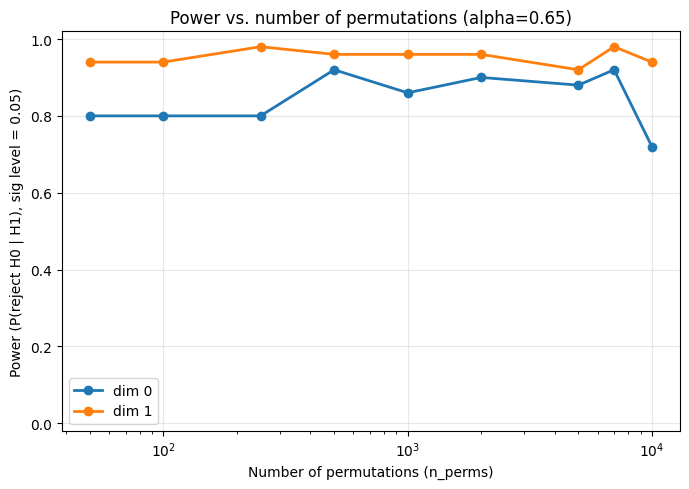


=== alpha=0.50 ===
n_perms=   50  dim=0  ->  power=0.620  (alpha=0.50, 50 reps)
n_perms=   50  dim=1  ->  power=0.740  (alpha=0.50, 50 reps)
n_perms=  100  dim=0  ->  power=0.640  (alpha=0.50, 50 reps)
n_perms=  100  dim=1  ->  power=0.760  (alpha=0.50, 50 reps)
n_perms=  250  dim=0  ->  power=0.600  (alpha=0.50, 50 reps)
n_perms=  250  dim=1  ->  power=0.820  (alpha=0.50, 50 reps)
n_perms=  500  dim=0  ->  power=0.580  (alpha=0.50, 50 reps)
n_perms=  500  dim=1  ->  power=0.660  (alpha=0.50, 50 reps)
n_perms= 1000  dim=0  ->  power=0.560  (alpha=0.50, 50 reps)
n_perms= 1000  dim=1  ->  power=0.800  (alpha=0.50, 50 reps)
n_perms= 2000  dim=0  ->  power=0.480  (alpha=0.50, 50 reps)
n_perms= 2000  dim=1  ->  power=0.900  (alpha=0.50, 50 reps)
n_perms= 5000  dim=0  ->  power=0.540  (alpha=0.50, 50 reps)
n_perms= 5000  dim=1  ->  power=0.720  (alpha=0.50, 50 reps)
n_perms= 7000  dim=0  ->  power=0.560  (alpha=0.50, 50 reps)
n_perms= 7000  dim=1  ->  power=0.760  (alpha=0.50, 50 reps)
n_pe

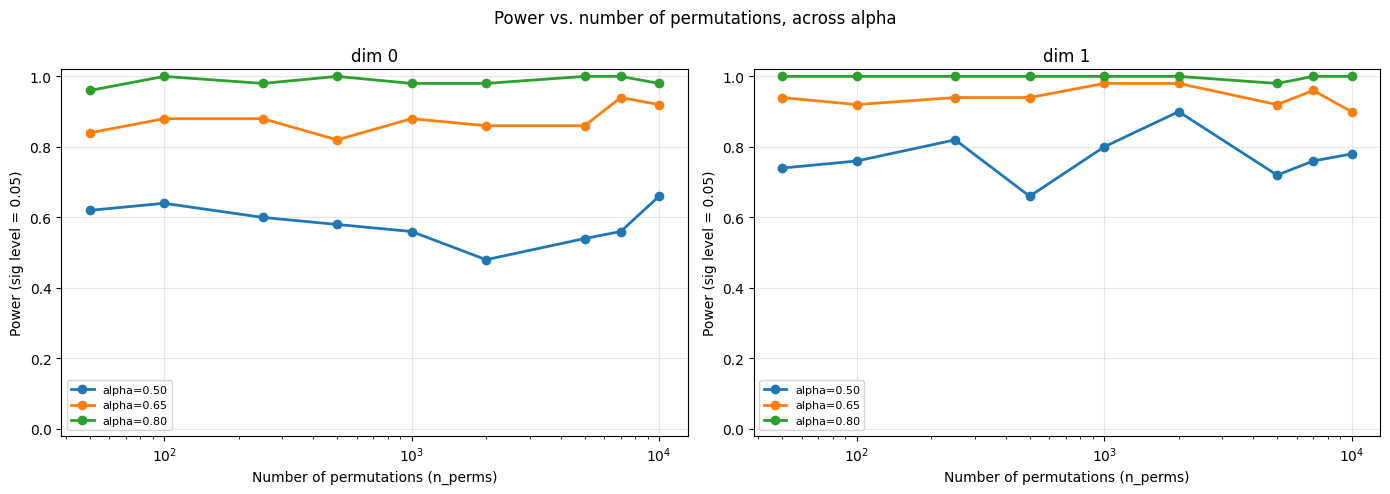

n_perms=   50  dim=0  ->  power=0.820  (alpha=0.65, 50 reps)
n_perms=   50  dim=1  ->  power=0.780  (alpha=0.65, 50 reps)
n_perms=  100  dim=0  ->  power=0.780  (alpha=0.65, 50 reps)
n_perms=  100  dim=1  ->  power=0.780  (alpha=0.65, 50 reps)
n_perms=  250  dim=0  ->  power=0.760  (alpha=0.65, 50 reps)
n_perms=  250  dim=1  ->  power=0.860  (alpha=0.65, 50 reps)
n_perms=  500  dim=0  ->  power=0.920  (alpha=0.65, 50 reps)
n_perms=  500  dim=1  ->  power=0.860  (alpha=0.65, 50 reps)
n_perms= 1000  dim=0  ->  power=0.800  (alpha=0.65, 50 reps)
n_perms= 1000  dim=1  ->  power=0.740  (alpha=0.65, 50 reps)
n_perms= 2000  dim=0  ->  power=0.860  (alpha=0.65, 50 reps)
n_perms= 2000  dim=1  ->  power=0.740  (alpha=0.65, 50 reps)
n_perms= 5000  dim=0  ->  power=0.840  (alpha=0.65, 50 reps)
n_perms= 5000  dim=1  ->  power=0.820  (alpha=0.65, 50 reps)
n_perms= 7000  dim=0  ->  power=0.760  (alpha=0.65, 50 reps)
n_perms= 7000  dim=1  ->  power=0.740  (alpha=0.65, 50 reps)
n_perms=10000  dim=0  ->

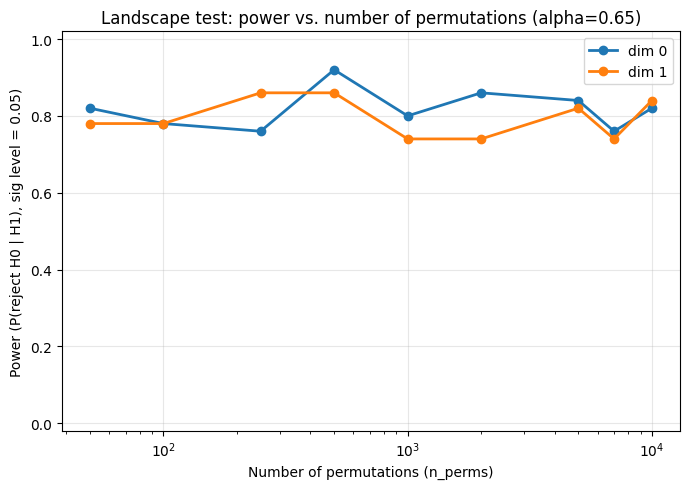

In [ ]:
# --- Single alpha, R&T permutation test ---
n_perms_values = [50, 100, 250, 500, 1000, 2000, 5000, 7000, 10000]

power_results = power_vs_nperms(A, alpha=0.65, n_perms_values=n_perms_values,
                                  n_reps=50, dims=(0, 1),
                                  n_subsamples=20, subsample_size=50,
                                  sig_level=0.05, seed=0)

plot_power_vs_nperms(power_results, alpha=0.65)


# --- Multiple alphas, R&T permutation test ---
alphas_to_test = [0.5, 0.65, 0.8]

power_results_multi = power_vs_nperms_multi_alpha(A, alphas_to_test, n_perms_values,
                                                     n_reps=50, dims=(0, 1),
                                                     n_subsamples=20, subsample_size=50,
                                                     sig_level=0.05, seed=0)

plot_power_vs_nperms_multi_alpha(power_results_multi, dims=(0, 1))


# --- Single alpha, landscape-based permutation test ---
power_results_landscape = power_vs_nperms_landscape(A, alpha=0.65,
                                  n_perms_values=n_perms_values,
                                  n_reps=50, dims=(0, 1),
                                  n_subsamples=20, subsample_size=50,
                                  num_steps=500,
                                  age_std_ratio=0.5, severity_std_ratio=0.5,
                                  ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                                  sig_level=0.05, seed=0)

plot_power_vs_nperms_landscape(power_results_landscape, alpha=0.65)

In [ ]:
# Same sensitivity sweep as run_sensitivity_sweep, but using the landscape permutation test instead of the R&T (F-loss) permutation test

def run_sensitivity_sweep_landscape(A, alphas, dims=(0, 1),
                     n_subsamples=200,
                     subsample_size=200,
                     n_perms=1000,
                     num_steps=500,
                     age_std_ratio=1, severity_std_ratio=1,
                     ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                     seed=0):
    results = []
    n_patients = n_subsamples * subsample_size

    for alpha in alphas:
        B = shift_distribution(A, alpha,
                                age_std_ratio=age_std_ratio,
                                severity_std_ratio=severity_std_ratio,
                                ring_radius_ratio=ring_radius_ratio,
                                ring_thickness_ratio=ring_thickness_ratio)

        X_A, y_A = data_hospital(A, n=n_patients)
        X_B, y_B = data_hospital(B, n=n_patients)

        X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

        dgms_A_samples = sample_diagrams_nonoverlapping(X_A_scaled,
                                          n_subsamples=n_subsamples,
                                          subsample_size=subsample_size)
        dgms_B_samples = sample_diagrams_nonoverlapping(X_B_scaled,
                                          n_subsamples=n_subsamples,
                                          subsample_size=subsample_size)
        dgms_samples_list = [dgms_A_samples, dgms_B_samples]

        for dim in dims:
            g_start, g_stop = get_global_range(dgms_samples_list, hom_deg=dim)
            pval = permutation_landscapes(dgms_samples_list,
                                           global_start=g_start, global_stop=g_stop,
                                           n_perms=n_perms, hom_deg=dim,
                                           num_steps=num_steps, seed=seed)
            results.append({"alpha": alpha, "dim": dim, "p_value": pval})
            print(f"alpha={alpha:.2f}  dim={dim}  ->  p={pval:.4f}")

    return results


def plot_alpha_sweep_landscape(sweep_results, alpha_level=0.05,
                                title="Landscape permutation test p-value vs. alpha"):
    dims = sorted(set(r["dim"] for r in sweep_results))
    fig, ax = plt.subplots(figsize=(7, 5))

    for dim in dims:
        rows = [r for r in sweep_results if r["dim"] == dim]
        rows.sort(key=lambda r: r["alpha"])
        alphas = [r["alpha"] for r in rows]
        pvals  = [r["p_value"] for r in rows]
        ax.plot(alphas, pvals, marker="o", linewidth=2, label=f"dim {dim}")

    ax.axhline(alpha_level, color="red", linestyle="--", linewidth=1,
               label=f"significance level ({alpha_level})")
    ax.set_xlabel(r"$\alpha$ (variance shift strength)")
    ax.set_ylabel("p-value")
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Draw non-overlapping subsamples of raw covariate rows (parallel to sample_diagrams_nonoverlapping, but returns raw data instead of persistence diagrams)

def sample_raw_nonoverlapping(X, n_subsamples=6, subsample_size=50, seed=0):

    rng = np.random.default_rng(seed)
    n_needed = n_subsamples * subsample_size
    assert n_needed <= len(X), f"Need {n_needed} rows, only have {len(X)}"

    idx = rng.permutation(len(X))[:n_needed]
    return [X[idx[i*subsample_size:(i+1)*subsample_size]] for i in range(n_subsamples)]

In [ ]:
# Wasserstein distance test on the raw data

def precompute_distances_raw(X_samples, order=2):

    m = len(X_samples)
    D = np.zeros((m, m))
    for i in range(m):
        for j in range(i + 1, m):
            a = np.ones(len(X_samples[i])) / len(X_samples[i])
            b = np.ones(len(X_samples[j])) / len(X_samples[j])
            M = ot.dist(X_samples[i], X_samples[j], metric='sqeuclidean')  # squared L2 ground cost
            d = ot.emd2(a, b, M) ** 0.5   # sqrt gives true W_2 distance
            D[i, j] = D[j, i] = d
    return D

In [ ]:
# Permutation test analogous to permutation_test(), but run directly on raw covariate subsamples instead of persistence diagrams

def permutation_test_raw(X_samples_list, n_perms=1000, order=2, q=2, seed=0):
    rng = np.random.default_rng(seed)

    pooled_samples = sum(X_samples_list, [])
    group_sizes = [len(s) for s in X_samples_list]
    labels = np.concatenate([np.full(n_m, m) for m, n_m in enumerate(group_sizes)])

    D_pooled = precompute_distances_raw(pooled_samples, order=order)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(X_samples_list))]
    F_L_obs = F_from_distance_matrix(D_pooled, idx_groups_obs, q=q)

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(X_samples_list))]
        F_L = F_from_distance_matrix(D_pooled, idx_groups_perm, q=q)
        if F_L <= F_L_obs:
            Z += 1

    return Z / (n_perms + 1)

In [ ]:
# Same sensitivity sweep as run_sensitivity_sweep, but using the raw-covariate Wasserstein permutation test instead of persistence diagrams

def run_sensitivity_sweep_raw(A, alphas,
                     n_subsamples=200,
                     subsample_size=200,
                     n_perms=1000,
                     order=2, q=2,
                     age_std_ratio=1, severity_std_ratio=1,
                     ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                     seed=0):
    rng = np.random.default_rng(seed)
    results = []
    n_patients = n_subsamples * subsample_size  # exact patients needed for non-overlapping sampling

    for alpha in alphas:
        B = shift_distribution(A, alpha,
                                age_std_ratio=age_std_ratio,
                                severity_std_ratio=severity_std_ratio,
                                ring_radius_ratio=ring_radius_ratio,
                                ring_thickness_ratio=ring_thickness_ratio)

        X_A, y_A = data_hospital(A, n=n_patients)
        X_B, y_B = data_hospital(B, n=n_patients)

        X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

        X_A_samples = sample_raw_nonoverlapping(X_A_scaled,
                                          n_subsamples=n_subsamples,
                                          subsample_size=subsample_size,
                                          seed=seed)
        X_B_samples = sample_raw_nonoverlapping(X_B_scaled,
                                          n_subsamples=n_subsamples,
                                          subsample_size=subsample_size,
                                          seed=seed)

        X_samples_list = [X_A_samples, X_B_samples]

        pval = permutation_test_raw(X_samples_list,
                                 n_perms=n_perms,
                                 order=order, q=q,
                                 seed=seed)
        results.append({"alpha": alpha, "p_value": pval})
        print(f"alpha={alpha:.2f}  ->  p={pval:.4f}")

    return results

In [ ]:
# Plot the raw-covariate permutation test p-value vs. alpha

def plot_alpha_sweep_raw(sweep_results, alpha_level=0.05, title="Raw-data Wasserstein permutation test p-value vs. alpha"):
    fig, ax = plt.subplots(figsize=(7, 5))

    rows = sorted(sweep_results, key=lambda r: r["alpha"])
    alphas = [r["alpha"] for r in rows]
    pvals  = [r["p_value"] for r in rows]
    ax.plot(alphas, pvals, marker="o", linewidth=2, color="crimson", label="Raw-covariate permutation test")

    ax.axhline(alpha_level, color="red", linestyle="--", linewidth=1,
               label=f"significance level ({alpha_level})")
    ax.set_xlabel(r"$\alpha$ (variance shift strength)")
    ax.set_ylabel("p-value")
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# For each alpha, repeat n_reps times: draw fresh hospital data and compute p-values from all three tests
# (R&T, landscape, raw-Wasserstein) on the same draws, so their power can be compared directly

def run_power_sweep(A, alphas, n_reps=20,
                     dims=(0, 1),
                     n_subsamples=20, subsample_size=50,
                     n_perms=1000,
                     age_std_ratio=1, severity_std_ratio=1,
                     ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                     alpha_level=0.05, seed=0):

    n_needed = n_subsamples * subsample_size
    records = []  # raw per-rep p-values, before aggregating into power

    for alpha in alphas:
        print(f"\n=== alpha = {alpha:.2f} ===")
        for rep in range(n_reps):
            rep_seed = seed + rep  # vary the draw each rep, keep alpha fixed
            rng_state = rep_seed

            B = shift_distribution(A, alpha,
                                    age_std_ratio=age_std_ratio,
                                    severity_std_ratio=severity_std_ratio,
                                    ring_radius_ratio=ring_radius_ratio,
                                    ring_thickness_ratio=ring_thickness_ratio)

            X_A, y_A = data_hospital(A, n=n_needed)
            X_B, y_B = data_hospital(B, n=n_needed)
            X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

            # --- diagrams (shared between R&T and landscape tests) ---
            dgms_A_samples = sample_diagrams_nonoverlapping(
                X_A_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size)
            dgms_B_samples = sample_diagrams_nonoverlapping(
                X_B_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size)
            dgms_samples_list = [dgms_A_samples, dgms_B_samples]

            for dim in dims:
                # R&T permutation test
                rt_pval = permutation_test(dgms_samples_list, n_perms=n_perms, dim=dim, seed=rng_state)
                records.append({"alpha": alpha, "rep": rep, "dim": dim, "method": "R&T", "p_value": rt_pval})

                # Landscape permutation test
                g_start, g_stop = get_global_range(dgms_samples_list, hom_deg=dim)
                land_pval = permutation_landscapes(
                    dgms_samples_list, global_start=g_start, global_stop=g_stop,
                    n_perms=n_perms, hom_deg=dim, seed=rng_state
                )
                records.append({"alpha": alpha, "rep": rep, "dim": dim, "method": "Landscape", "p_value": land_pval})

            # --- raw-covariate Wasserstein permutation test (dim-agnostic) ---
            X_A_samples = sample_raw_nonoverlapping(
                X_A_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size, seed=rng_state)
            X_B_samples = sample_raw_nonoverlapping(
                X_B_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size, seed=rng_state)
            raw_pval = permutation_test_raw([X_A_samples, X_B_samples], n_perms=n_perms, order=2, q=2, seed=rng_state)
            records.append({"alpha": alpha, "rep": rep, "dim": None, "method": "Raw-Wasserstein", "p_value": raw_pval})

        print(f"  completed {n_reps} reps")

    # --- aggregate into power ---
    power_results = []
    for alpha in alphas:
        for method in ["R&T", "Landscape"]:
            for dim in dims:
                pvals = [r["p_value"] for r in records
                         if r["alpha"] == alpha and r["method"] == method and r["dim"] == dim]
                power = np.mean([p < alpha_level for p in pvals])
                power_results.append({"alpha": alpha, "dim": dim, "method": method, "power": power})

        pvals_raw = [r["p_value"] for r in records
                     if r["alpha"] == alpha and r["method"] == "Raw-Wasserstein"]
        power_raw = np.mean([p < alpha_level for p in pvals_raw])
        power_results.append({"alpha": alpha, "dim": None, "method": "Raw-Wasserstein", "power": power_raw})

    return power_results, records

In [ ]:
# Plot statistical power vs. alpha for each (method, dim) combination — power = fraction of reps with p < alpha_level

def plot_power_sweep(power_results, alpha_level=0.05,
                      title="Statistical power vs. alpha shift strength"):
    # group by (method, dim) — dim is None for the raw-covariate method
    keys = sorted(set((r["method"], r["dim"]) for r in power_results),
                  key=lambda k: (k[0], -1 if k[1] is None else k[1]))

    fig, ax = plt.subplots(figsize=(8, 5))

    style_map = {
        "R&T": {"color": "teal", "marker": "s"},
        "Landscape": {"color": "darkorange", "marker": "^"},
        "Raw-Wasserstein": {"color": "crimson", "marker": "d"},
    }

    # explicit dash pattern per dim so it's unambiguous in the legend
    dash_map = {
        0: (None, None),      # solid
        1: (4, 2),            # dashed: 4pt on, 2pt off
        None: (None, None),   # solid (raw-covariate method has no dim)
    }

    for method, dim in keys:
        rows = [r for r in power_results if r["method"] == method and r["dim"] == dim]
        rows.sort(key=lambda r: r["alpha"])
        alphas = [r["alpha"] for r in rows]
        powers = [r["power"] for r in rows]

        label = f"{method}" if dim is None else f"{method}, dim {dim}"
        style = style_map.get(method, {})

        line, = ax.plot(alphas, powers, marker=style.get("marker", "o"),
                         color=style.get("color"),
                         linewidth=2, label=label)
        line.set_dashes(dash_map.get(dim, (None, None)))

    ax.axhline(0.05, color="gray", linestyle=":", linewidth=1, label="nominal size (0.05)")
    ax.set_xlabel(r"$\alpha$ (variance shift strength)")
    ax.set_ylabel(f"Power (fraction of reps with p < {alpha_level})")
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8, handlelength=3.5)  # longer handles so dashes are visible
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Estimate power as a function of the number of subsamples (m), for a fixed subsample size and effect size (alpha)

def power_vs_nsubsamples(A, alpha, nsubsamples_values, n_reps=50, dims=(0, 1),
                          subsample_size=50, n_perms=1000,
                          p=2, internal_p=2, q=2,
                          age_std_ratio=0.5, severity_std_ratio=0.5,
                          ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
                          sig_level=0.05, seed=0):

    rng_master = np.random.default_rng(seed)

    B = shift_distribution(A, alpha,
                            age_std_ratio=age_std_ratio,
                            severity_std_ratio=severity_std_ratio,
                            ring_radius_ratio=ring_radius_ratio,
                            ring_thickness_ratio=ring_thickness_ratio)

    power_results = []
    pval_records = []

    for n_subsamples in nsubsamples_values:
        n_patients = n_subsamples * subsample_size
        pvals_by_dim = {dim: [] for dim in dims}

        for rep in range(n_reps):
            X_A, y_A = data_hospital(A, n=n_patients)
            X_B, y_B = data_hospital(B, n=n_patients)
            X_A_scaled, X_B_scaled = preprocess_pooled(X_A, X_B)

            dgms_A_samples = sample_diagrams_nonoverlapping(
                X_A_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                seed=int(rng_master.integers(1e9))
            )
            dgms_B_samples = sample_diagrams_nonoverlapping(
                X_B_scaled, n_subsamples=n_subsamples, subsample_size=subsample_size,
                seed=int(rng_master.integers(1e9))
            )
            dgms_samples_list = [dgms_A_samples, dgms_B_samples]

            for dim in dims:
                pval = permutation_test(dgms_samples_list,
                                         n_perms=n_perms, dim=dim,
                                         order=p, internal_p=internal_p, q=q,
                                         seed=int(rng_master.integers(1e9)))
                pvals_by_dim[dim].append(pval)
                pval_records.append({
                    "n_subsamples": n_subsamples, "dim": dim,
                    "rep": rep, "p_value": pval,
                })

        for dim in dims:
            pvals = np.array(pvals_by_dim[dim])
            power = np.mean(pvals < sig_level)
            power_results.append({
                "n_subsamples": n_subsamples, "dim": dim,
                "power": power,
                "mean_pvalue": pvals.mean(),
                "std_pvalue": pvals.std(),
            })
            print(f"n_subsamples={n_subsamples:5d}  dim={dim}  ->  "
                  f"power={power:.3f}  mean p={pvals.mean():.4f}  "
                  f"(alpha={alpha:.2f}, subsample_size={subsample_size}, {n_reps} reps)")

    return power_results, pval_records


def plot_power_vs_nsubsamples(power_results, alpha, subsample_size, sig_level=0.05):
    dims = sorted(set(r["dim"] for r in power_results))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for dim in dims:
        rows = [r for r in power_results if r["dim"] == dim]
        rows.sort(key=lambda r: r["n_subsamples"])
        n_subs = [r["n_subsamples"] for r in rows]
        powers = [r["power"] for r in rows]
        mean_pvals = [r["mean_pvalue"] for r in rows]

        axes[0].plot(n_subs, powers, marker="o", linewidth=2, label=f"dim {dim}")
        axes[1].plot(n_subs, mean_pvals, marker="o", linewidth=2, label=f"dim {dim}")

    axes[0].set_xlabel("Number of diagrams per group (n_subsamples)")
    axes[0].set_ylabel(f"Power (fraction of reps with p < {sig_level})")
    axes[0].set_title(f"Power vs. n_subsamples (alpha={alpha:.2f}, subsample_size={subsample_size})")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].axhline(sig_level, color="red", linestyle="--", linewidth=1,
                     label=f"significance level ({sig_level})")
    axes[1].set_xlabel("Number of diagrams per group (n_subsamples)")
    axes[1].set_ylabel("Mean p-value")
    axes[1].set_title(f"Mean p-value vs. n_subsamples (alpha={alpha:.2f}, subsample_size={subsample_size})")
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

alpha=0.00  dim=0  ->  p=0.6653
alpha=0.00  dim=1  ->  p=0.8422
alpha=0.14  dim=0  ->  p=0.7772
alpha=0.14  dim=1  ->  p=0.8551
alpha=0.29  dim=0  ->  p=0.4486
alpha=0.29  dim=1  ->  p=0.4436
alpha=0.43  dim=0  ->  p=0.0160
alpha=0.43  dim=1  ->  p=0.2557
alpha=0.57  dim=0  ->  p=0.0130
alpha=0.57  dim=1  ->  p=0.1299
alpha=0.71  dim=0  ->  p=0.0050
alpha=0.71  dim=1  ->  p=0.0010
alpha=0.86  dim=0  ->  p=0.0010
alpha=0.86  dim=1  ->  p=0.0010
alpha=1.00  dim=0  ->  p=0.0230
alpha=1.00  dim=1  ->  p=0.0030


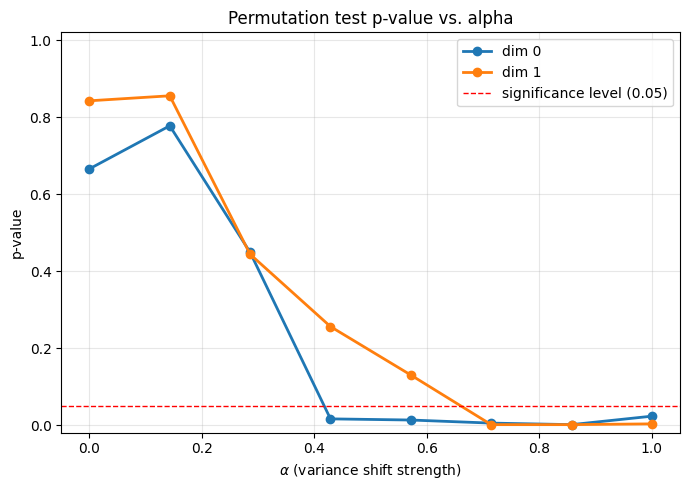

In [ ]:
# Run the R&T sensitivity sweep across alpha and plot the resulting p-values

ALPHAS = np.linspace(0.0, 1.0, 8)
res = run_sensitivity_sweep(A, ALPHAS, dims=(0, 1),
                            n_subsamples=20,subsample_size=50,
                            n_perms=1000,p=2, internal_p=2, q=2,
                            age_std_ratio=1, severity_std_ratio=1,
                            ring_radius_ratio=0, ring_thickness_ratio=0.5,seed=0)
plot_alpha_sweep(res)

p=1 q=1 alpha=0.00 dim=0 -> mean p=0.4896, power=0.00
p=1 q=1 alpha=0.00 dim=1 -> mean p=0.4809, power=0.00
p=1 q=1 alpha=0.14 dim=0 -> mean p=0.4908, power=0.00
p=1 q=1 alpha=0.14 dim=1 -> mean p=0.0238, power=0.90
p=1 q=1 alpha=0.29 dim=0 -> mean p=0.2343, power=0.35
p=1 q=1 alpha=0.29 dim=1 -> mean p=0.0010, power=1.00
p=1 q=1 alpha=0.43 dim=0 -> mean p=0.0698, power=0.65
p=1 q=1 alpha=0.43 dim=1 -> mean p=0.0010, power=1.00
p=1 q=1 alpha=0.57 dim=0 -> mean p=0.0187, power=0.90
p=1 q=1 alpha=0.57 dim=1 -> mean p=0.0010, power=1.00
p=1 q=1 alpha=0.71 dim=0 -> mean p=0.0170, power=0.95
p=1 q=1 alpha=0.71 dim=1 -> mean p=0.0010, power=1.00
p=1 q=1 alpha=0.86 dim=0 -> mean p=0.0353, power=0.85
p=1 q=1 alpha=0.86 dim=1 -> mean p=0.0010, power=1.00
p=1 q=1 alpha=1.00 dim=0 -> mean p=0.0605, power=0.70
p=1 q=1 alpha=1.00 dim=1 -> mean p=0.0010, power=1.00
p=1 q=2 alpha=0.00 dim=0 -> mean p=0.4981, power=0.05
p=1 q=2 alpha=0.00 dim=1 -> mean p=0.4657, power=0.00
p=1 q=2 alpha=0.14 dim=0 -> 

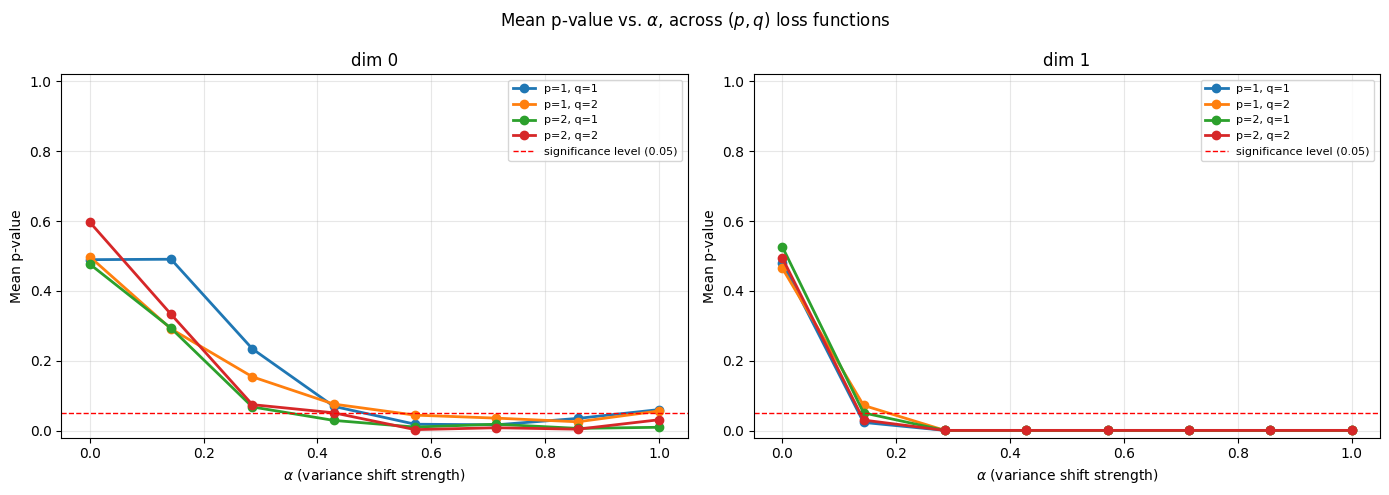

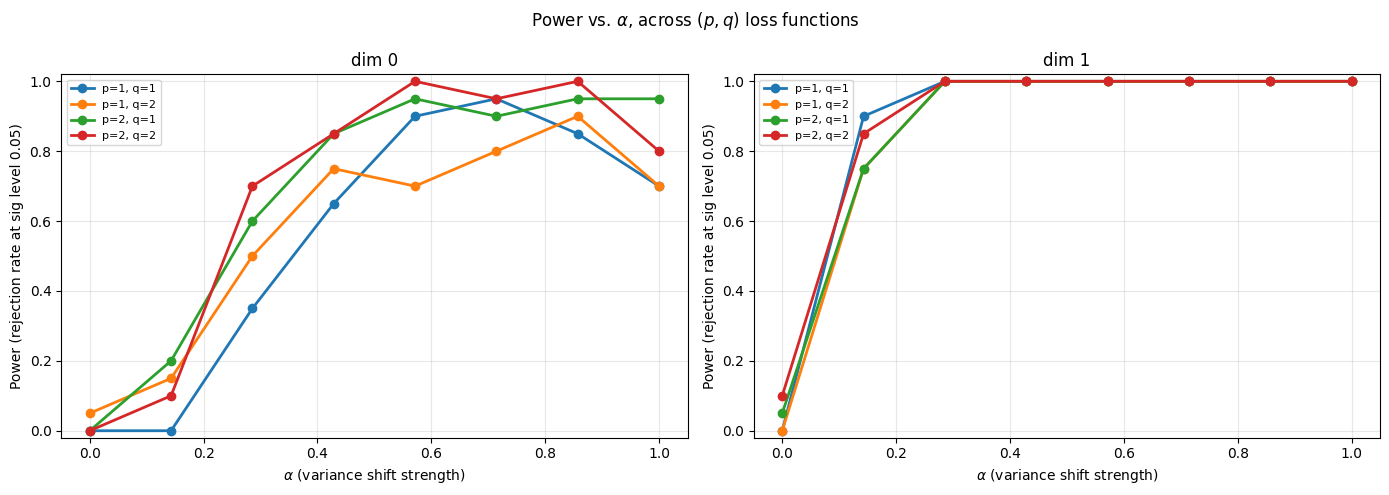

In [ ]:
# Compare (p, q) loss-function choices across alpha: mean p-value and power for each combination

pq_values = [(1, 1), (1, 2), (2, 1), (2, 2)]
ALPHAS = np.linspace(0.0, 1.0, 8)

pq_results = run_pq_comparison_full(
    A, ALPHAS, pq_values, dims=(0, 1),
    n_reps=20, n_subsamples=20, subsample_size=50,
    n_perms=1000, internal_p=2, sig_level=0.05,
    age_std_ratio=1, severity_std_ratio=1,
    ring_radius_ratio=0.5, ring_thickness_ratio=0.5,
    seed=0
)

plot_pq_pvalue_comparison(pq_results, dims=(0, 1))
plot_pq_power_comparison(pq_results, dims=(0, 1))

alpha=0.00  dim=0  ->  p=0.2208
alpha=0.00  dim=1  ->  p=0.1788
alpha=0.14  dim=0  ->  p=0.5225
alpha=0.14  dim=1  ->  p=0.2308
alpha=0.29  dim=0  ->  p=0.0060
alpha=0.29  dim=1  ->  p=0.1199
alpha=0.43  dim=0  ->  p=0.6324
alpha=0.43  dim=1  ->  p=0.3546
alpha=0.57  dim=0  ->  p=0.0360
alpha=0.57  dim=1  ->  p=0.0979
alpha=0.71  dim=0  ->  p=0.2308
alpha=0.71  dim=1  ->  p=0.0040
alpha=0.86  dim=0  ->  p=0.0020
alpha=0.86  dim=1  ->  p=0.0030
alpha=1.00  dim=0  ->  p=0.0010
alpha=1.00  dim=1  ->  p=0.0010


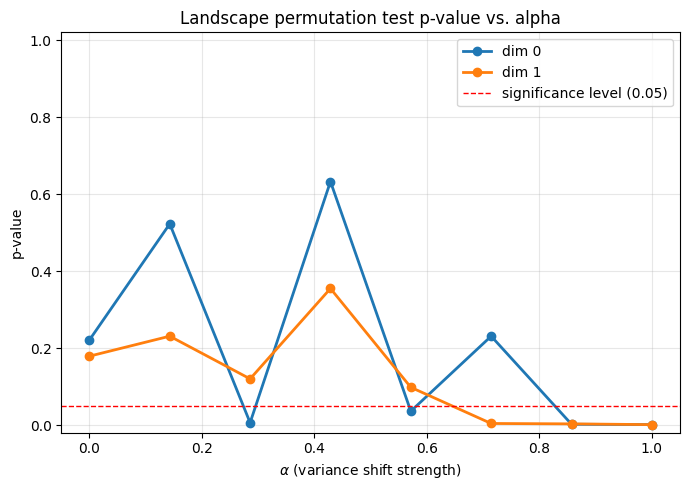

In [ ]:
# Run the landscape-based sensitivity sweep across alpha and plot the resulting p-values

ALPHAS = np.linspace(0.0, 1.0, 8)

res_landscape = run_sensitivity_sweep_landscape(A, ALPHAS, dims=(0, 1),
                     n_subsamples=20,
                     subsample_size=50,
                     n_perms=1000,
                     num_steps=500,
                     age_std_ratio=1, severity_std_ratio=1,
                     ring_radius_ratio=0, ring_thickness_ratio=0.5,
                     seed=0)

plot_alpha_sweep_landscape(res_landscape)

alpha=0.00  ->  p=0.6294
alpha=0.14  ->  p=0.4456
alpha=0.29  ->  p=0.0549
alpha=0.43  ->  p=0.0110
alpha=0.57  ->  p=0.0010
alpha=0.71  ->  p=0.0010
alpha=0.86  ->  p=0.0010
alpha=1.00  ->  p=0.0010


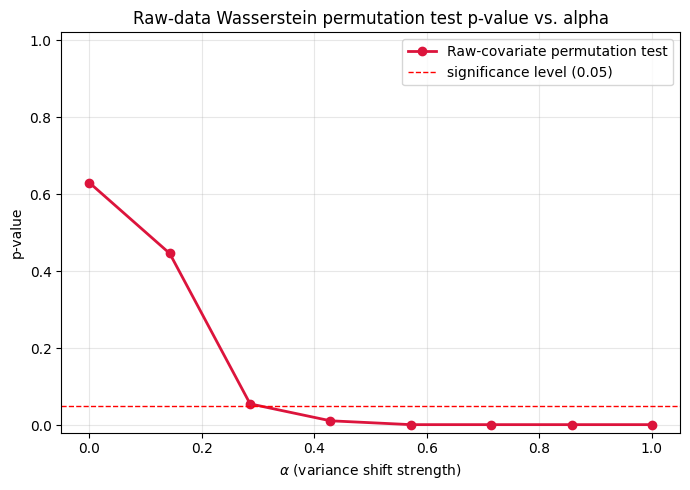

In [ ]:
# Run the raw-covariate Wasserstein sensitivity sweep across alpha and plot the resulting p-values

ALPHAS = np.linspace(0.0, 1.0, 8)

res_raw = run_sensitivity_sweep_raw(A, ALPHAS,
                     n_subsamples=20,
                     subsample_size=50,
                     n_perms=1000,
                     age_std_ratio=1, severity_std_ratio=1,
                     ring_radius_ratio=0, ring_thickness_ratio=0.5,
                     seed=0)

plot_alpha_sweep_raw(res_raw)


=== alpha = 0.00 ===
  completed 20 reps

=== alpha = 0.14 ===
  completed 20 reps

=== alpha = 0.29 ===
  completed 20 reps

=== alpha = 0.43 ===
  completed 20 reps

=== alpha = 0.57 ===
  completed 20 reps

=== alpha = 0.71 ===
  completed 20 reps

=== alpha = 0.86 ===
  completed 20 reps

=== alpha = 1.00 ===
  completed 20 reps


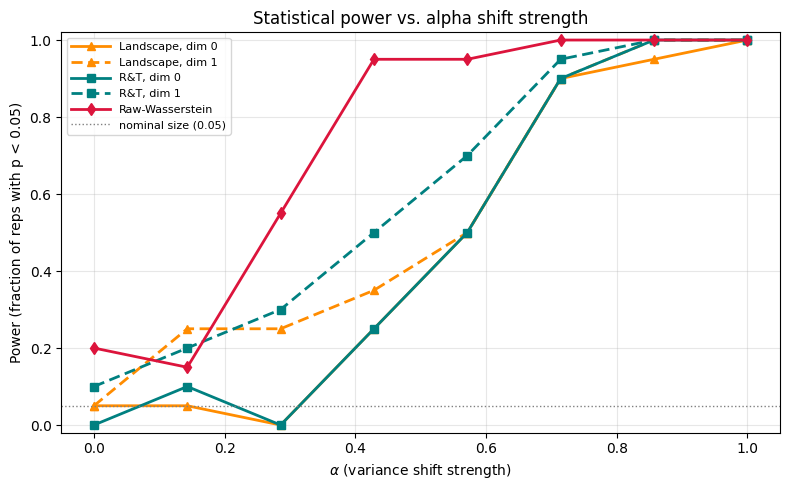

In [ ]:
# Try with n_reps = 100
ALPHAS = np.linspace(0.0, 1.0, 8)

power_results, raw_records = run_power_sweep(
    A, ALPHAS, n_reps=20, dims=(0, 1),
    n_subsamples=20, subsample_size=50, n_perms=1000,
    age_std_ratio=1, severity_std_ratio=1,
    ring_radius_ratio=0, ring_thickness_ratio=0.5,
    seed=0)
plot_power_sweep(power_results)

subsample_size=   20  dim=0  ->  power=0.660  mean p=0.0747  (alpha=0.80, 50 reps)
subsample_size=   20  dim=1  ->  power=0.280  mean p=0.2009  (alpha=0.80, 50 reps)
subsample_size=   30  dim=0  ->  power=0.800  mean p=0.0403  (alpha=0.80, 50 reps)
subsample_size=   30  dim=1  ->  power=0.740  mean p=0.0399  (alpha=0.80, 50 reps)
subsample_size=   50  dim=0  ->  power=0.940  mean p=0.0101  (alpha=0.80, 50 reps)
subsample_size=   50  dim=1  ->  power=0.980  mean p=0.0046  (alpha=0.80, 50 reps)
subsample_size=   75  dim=0  ->  power=1.000  mean p=0.0027  (alpha=0.80, 50 reps)
subsample_size=   75  dim=1  ->  power=1.000  mean p=0.0010  (alpha=0.80, 50 reps)
subsample_size=  100  dim=0  ->  power=1.000  mean p=0.0012  (alpha=0.80, 50 reps)
subsample_size=  100  dim=1  ->  power=1.000  mean p=0.0010  (alpha=0.80, 50 reps)
subsample_size=  150  dim=0  ->  power=1.000  mean p=0.0010  (alpha=0.80, 50 reps)
subsample_size=  150  dim=1  ->  power=1.000  mean p=0.0010  (alpha=0.80, 50 reps)
subs

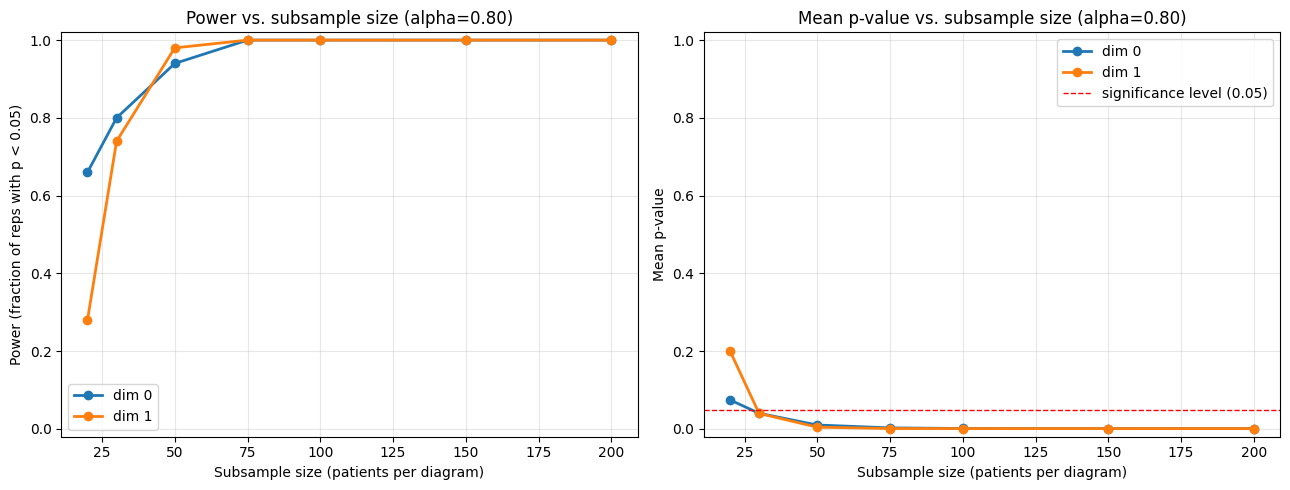

In [ ]:
# Estimate power as a function of subsample size (patients per diagram) at a fixed, strong effect size (alpha=0.8)

SAMPLE_SIZES = [20, 30, 50, 75, 100, 150, 200]

power_results_samplesize, pval_records_samplesize = power_vs_samplesize(
    A, alpha=0.8, sample_sizes=SAMPLE_SIZES,
    n_reps=50, dims=(0, 1),
    n_subsamples=20, n_perms=1000,
    age_std_ratio=1, severity_std_ratio=1,
    ring_radius_ratio=0, ring_thickness_ratio=0.5,
    sig_level=0.05, seed=0)

plot_power_vs_samplesize(power_results_samplesize, alpha=0.8)

n_subsamples=    5  dim=0  ->  power=0.240  mean p=0.2308  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=    5  dim=1  ->  power=0.480  mean p=0.1444  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   10  dim=0  ->  power=0.600  mean p=0.0650  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   10  dim=1  ->  power=0.840  mean p=0.0307  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   15  dim=0  ->  power=0.800  mean p=0.0319  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   15  dim=1  ->  power=0.960  mean p=0.0168  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   20  dim=0  ->  power=0.960  mean p=0.0135  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   20  dim=1  ->  power=1.000  mean p=0.0018  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   30  dim=0  ->  power=1.000  mean p=0.0013  (alpha=0.80, subsample_size=50, 50 reps)
n_subsamples=   30  dim=1  ->  power=1.000  mean p=0.0010  (alpha=0.80, subsample_size=50, 50 reps)


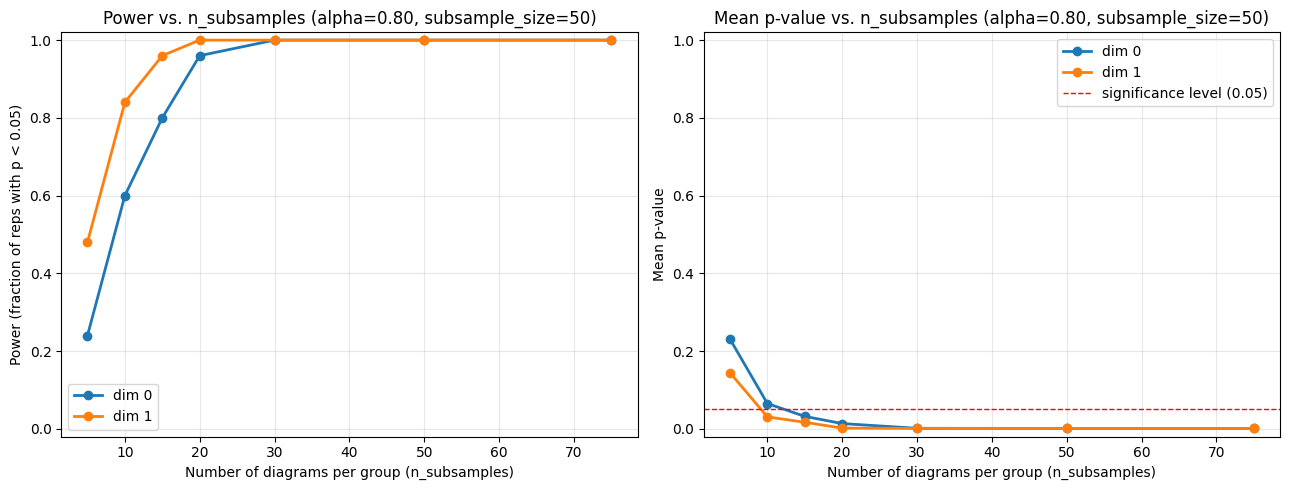

In [ ]:
# Estimate power as a function of the number of subsamples (m) at a fixed, strong effect size (alpha=0.8)

NSUBSAMPLES_VALUES = [5, 10, 15, 20, 30, 50, 75]

power_results_nsub, pval_records_nsub = power_vs_nsubsamples(
    A, alpha=0.8, nsubsamples_values=NSUBSAMPLES_VALUES,
    n_reps=50, dims=(0, 1),
    subsample_size=50, n_perms=1000,
    age_std_ratio=1, severity_std_ratio=1,
    ring_radius_ratio=0.0, ring_thickness_ratio=0.5,
    sig_level=0.05, seed=0)

plot_power_vs_nsubsamples(power_results_nsub, alpha=0.8, subsample_size=50)